# S&P 500 Stock Data Analysis (2013-2018)

Analysis of historical stock quotations for S&P 500 companies, including:
- Data quality checks
- Daily returns calculation
- Rolling windows correlation

## 1. Import Libraries and Load Data

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [20]:
# Load the extracted data
FILE_NAME = 'data_10_24'
data_path = Path(f'../data/processed/{FILE_NAME}.csv')
df = pd.read_csv(data_path, parse_dates=['timestamp'])


print(f"Timestamp range: {df['timestamp'].min().strftime('%Y-%m-%d')} to {df['timestamp'].max().strftime('%Y-%m-%d')}")
print(f"Total records: {len(df)}")

# Extract ticker names (excluding timestamp)
ticker_cols = df.columns[1:].tolist()

# Core representation: pandas DataFrame (excluding timestamp)
prices_df = df[ticker_cols].copy()

# Display basic information
print("\nDataset shape (excluding timestamp):", prices_df.shape, "# (rows=time, cols=tickers)")
print("N. of dates (rows):", prices_df.shape[0])
print("N. of tickers/stocks (columns):", prices_df.shape[1])
print("\nColumn names (tickers/stocks):")
print(ticker_cols)
print("\nFirst few rows:")
print(prices_df.head())

Timestamp range: 2010-01-04 to 2024-12-20
Total records: 3768

Dataset shape (excluding timestamp): (3768, 502) # (rows=time, cols=tickers)
N. of dates (rows): 3768
N. of tickers/stocks (columns): 502

Column names (tickers/stocks):
['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMTM', 'AMZN', 'ANET', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APTV', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BF-B', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRK-B', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CE', 'CEG', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CINF', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COO', 'COP', 'CO

In [21]:
def plot_quotations_per_day(quotes_per_day, max_quotes, file_name, is_filtered=False, 
                            min_quotes=None, n_days=None):
    """
    Plot three subplots showing quotations per day statistics.
    
    Parameters:
    -----------
    quotes_per_day : pd.Series
        Series with number of quotations per day
    max_quotes : int
        Maximum possible quotations (total number of tickers)
    file_name : str
        Name of the dataset file for title
    is_filtered : bool
        Whether data is filtered (affects title)
    min_quotes : int
        Minimum quotations threshold (optional, for filtered plot titles)
    n_days : int
        Total number of days in original dataset (for histogram limits)
    """
    # Create three subplots stacked vertically
    fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(14, 12))
    
    quotations_values = quotes_per_day.values
    bin_width = max_quotes / 50
    bins_sequence = [i * bin_width for i in range(51)]
    
    # Determine title suffix
    title_suffix = f" - FILTERED (> {min_quotes} quotations)" if is_filtered else ""
    xlabel_suffix = "Days" if is_filtered else "Timeline"
    
    # Plot 1: Time series of quotations per day
    ax0.plot(range(len(quotes_per_day)), quotations_values, linewidth=1.5, color='steelblue')
    ax0.axhline(y=max_quotes, color='red', linestyle='--', linewidth=2, label=f'Max Quotations ({max_quotes})')
    ax0.set_xlim(0, len(quotes_per_day) - 1)
    ax0.set_ylim(0, max_quotes * 1.1)
    ax0.legend(loc='upper right', fontsize=10, shadow=True)
    ax0.set_xlabel(xlabel_suffix, fontsize=12, fontweight='bold')
    ax0.set_ylabel('Count (Quotations)', fontsize=12, fontweight='bold')
    ax0.set_title(f'Available Quotations per Day Over Time (S&P 500 - {file_name}){title_suffix}', 
                  fontsize=13, fontweight='bold')
    ax0.grid(True, alpha=0.3)
    
    # Plot 2: Full histogram
    ax1.hist(quotations_values, bins=bins_sequence, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlim(0, max_quotes + 1)
    ax1.set_ylim(0, (n_days if n_days else len(quotes_per_day)) * 1.1)
    ax1.set_xlabel('Number of Available Quotations', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count (Days)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Distribution of Daily Quotation Counts (S&P 500 - {file_name}){title_suffix}', 
                  fontsize=13, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 3: Absolute frequency histogram for values 0-10
    counts = pd.Series(quotes_per_day).value_counts().sort_index()
    for i in range(11):
        if i not in counts.index:
            counts[i] = 0
    counts = counts.sort_index()[:11]
    ax2.bar(range(11), counts.values, color='steelblue', edgecolor='black', alpha=0.7)
    ax2.set_xlim(-0.5, 10.5)
    ax2.set_ylim(0, counts.max() * 1.1)
    ax2.set_xlabel('Number of Available Quotations', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count (Days)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Distribution of Daily Quotation Counts (Zoom 0-10) (S&P 500 - {file_name}){title_suffix}', 
                  fontsize=13, fontweight='bold')
    ax2.set_xticks(range(11))
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 2. Data Quality Checks and Cleaning

This dataset is already cleaned with:
- Survival bias removed
- Ticker changes accounted for
- Stock splits/reverse splits handled

We'll verify data quality and set a minimum threshold for quotations per stock.

In [22]:
# Check for missing values with pandas
missing_per_col = prices_df.isna().sum()
total_missing = int(missing_per_col.sum())
n_cells = prices_df.shape[0] * prices_df.shape[1]
missing_pct = (total_missing / n_cells) * 100

print("Missing values per column:")
for ticker in ticker_cols:
    print(f"{ticker}: {missing_per_col[ticker]}")

print(f"\nTotal missing values: {total_missing}")
print(f"Missing percentage: {missing_pct:.2f}%")

Missing values per column:
A: 3768
AAPL: 3768
ABBV: 754
ABNB: 3768
ABT: 0
ACGL: 3768
ACN: 3768
ADBE: 3768
ADI: 3768
ADM: 0
ADP: 3768
ADSK: 3768
AEE: 3768
AEP: 3768
AES: 0
AFL: 3768
AIG: 3768
AIZ: 3768
AJG: 0
AKAM: 3768
ALB: 0
ALGN: 3768
ALL: 0
ALLE: 976
AMAT: 3768
AMCR: 3768
AMD: 3768
AME: 3768
AMGN: 3768
AMP: 0
AMT: 3768
AMTM: 3768
AMZN: 0
ANET: 1113
ANSS: 0
AON: 3768
AOS: 0
APA: 3768
APD: 3768
APH: 0
APTV: 3768
ARE: 3768
ATO: 3768
AVB: 3768
AVGO: 3768
AVY: 3768
AWK: 3768
AXON: 0
AXP: 0
AZO: 3768
BA: 3768
BAC: 3768
BALL: 3768
BAX: 0
BBY: 0
BDX: 0
BEN: 0
BF-B: 3768
BG: 3768
BIIB: 3768
BK: 0
BKNG: 3768
BKR: 0
BLDR: 0
BLK: 3768
BMY: 3768
BR: 3768
BRK-B: 3768
BRO: 0
BSX: 0
BWA: 0
BX: 3768
BXP: 3768
C: 0
CAG: 3768
CAH: 3768
CARR: 3768
CAT: 0
CB: 3768
CBOE: 3768
CBRE: 3768
CCI: 3768
CCL: 0
CDNS: 3768
CDW: 3768
CE: 0
CEG: 3768
CF: 3768
CFG: 3768
CHD: 3768
CHRW: 3768
CHTR: 3768
CI: 3768
CINF: 3768
CL: 3768
CLX: 0
CMCSA: 0
CME: 0
CMG: 3768
CMI: 3768
CMS: 3768
CNC: 3768
CNP: 3768
COF: 0
COO: 37

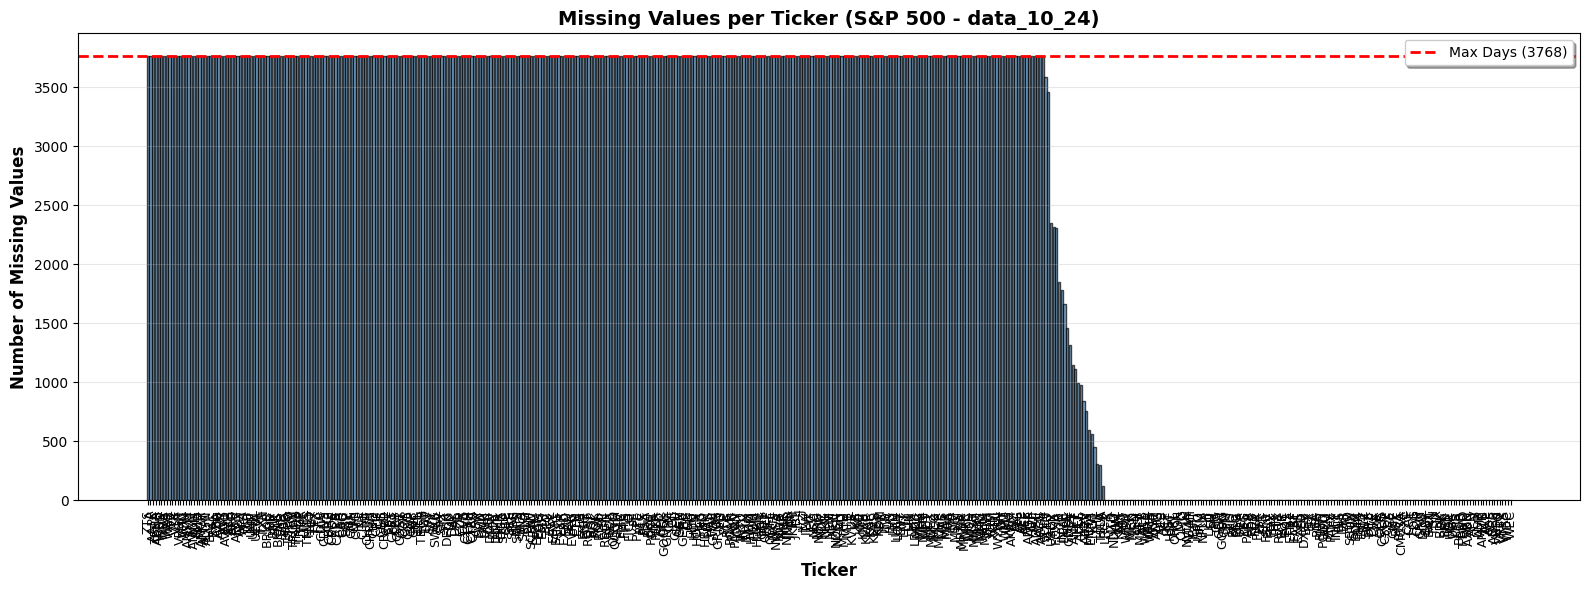

Missing values per ticker (sorted by count):
ZTS: 3768
A: 3768
AAPL: 3768
ZBRA: 3768
ABNB: 3768
WBD: 3768
WBA: 3768
WAT: 3768
WAB: 3768
VZ: 3768
VTR: 3768
VST: 3768
VRSN: 3768
VMC: 3768
AON: 3768
AMTM: 3768
AMT: 3768
AMGN: 3768
AME: 3768
AMD: 3768
AMCR: 3768
AMAT: 3768
ALGN: 3768
BALL: 3768
BAC: 3768
BA: 3768
AZO: 3768
AWK: 3768
AVY: 3768
AVGO: 3768
AVB: 3768
ATO: 3768
ARE: 3768
APTV: 3768
APD: 3768
APA: 3768
VICI: 3768
URI: 3768
UNP: 3768
UNH: 3768
ULTA: 3768
TYL: 3768
TXT: 3768
TXN: 3768
BRK-B: 3768
BR: 3768
BMY: 3768
BLK: 3768
BKNG: 3768
BIIB: 3768
BG: 3768
BF-B: 3768
TSCO: 3768
TRV: 3768
TROW: 3768
TRMB: 3768
TRGP: 3768
TPR: 3768
TPL: 3768
TMUS: 3768
TMO: 3768
TGT: 3768
TFX: 3768
TFC: 3768
CDW: 3768
CDNS: 3768
CCI: 3768
CBRE: 3768
CBOE: 3768
CB: 3768
CARR: 3768
CAH: 3768
CAG: 3768
BXP: 3768
BX: 3768
CMS: 3768
CMI: 3768
CMG: 3768
CL: 3768
CINF: 3768
CI: 3768
CHTR: 3768
CHRW: 3768
CHD: 3768
CFG: 3768
CF: 3768
CEG: 3768
CRWD: 3768
CRL: 3768
CPT: 3768
CPRT: 3768
CPB: 3768
CPAY: 3768
CO

In [23]:
# Histogram of missing values per ticker, sorted by bar height
missing_sorted = missing_per_col.sort_values(ascending=False)
sorted_tickers = missing_sorted.index.tolist()
max_days = prices_df.shape[0]  # Max possible missing values

plt.figure(figsize=(16, 6))
plt.bar(
    range(len(sorted_tickers)),
    missing_sorted.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.7,
 )
plt.axhline(y=max_days, color='red', linestyle='--', linewidth=2, label=f'Max Days ({max_days})')
plt.legend(loc='upper right', fontsize=10, shadow=True)
plt.xlabel('Ticker', fontsize=12, fontweight='bold')
plt.ylabel('Number of Missing Values', fontsize=12, fontweight='bold')
plt.title(f'Missing Values per Ticker (S&P 500 - {FILE_NAME})', fontsize=14, fontweight='bold')
plt.xticks(range(len(sorted_tickers)), sorted_tickers, rotation=90, fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Missing values per ticker (sorted by count):")
for ticker, n_missing in zip(sorted_tickers, missing_sorted.values):
    print(f"{ticker}: {int(n_missing)}")

Quotations per day (across all tickers):
Min: 150
Max: 172
Mean: 163.97
Std: 6.76


C:\Users\dylan\AppData\Local\Temp\ipykernel_11172\2384116002.py:62: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, counts.max() * 1.1)


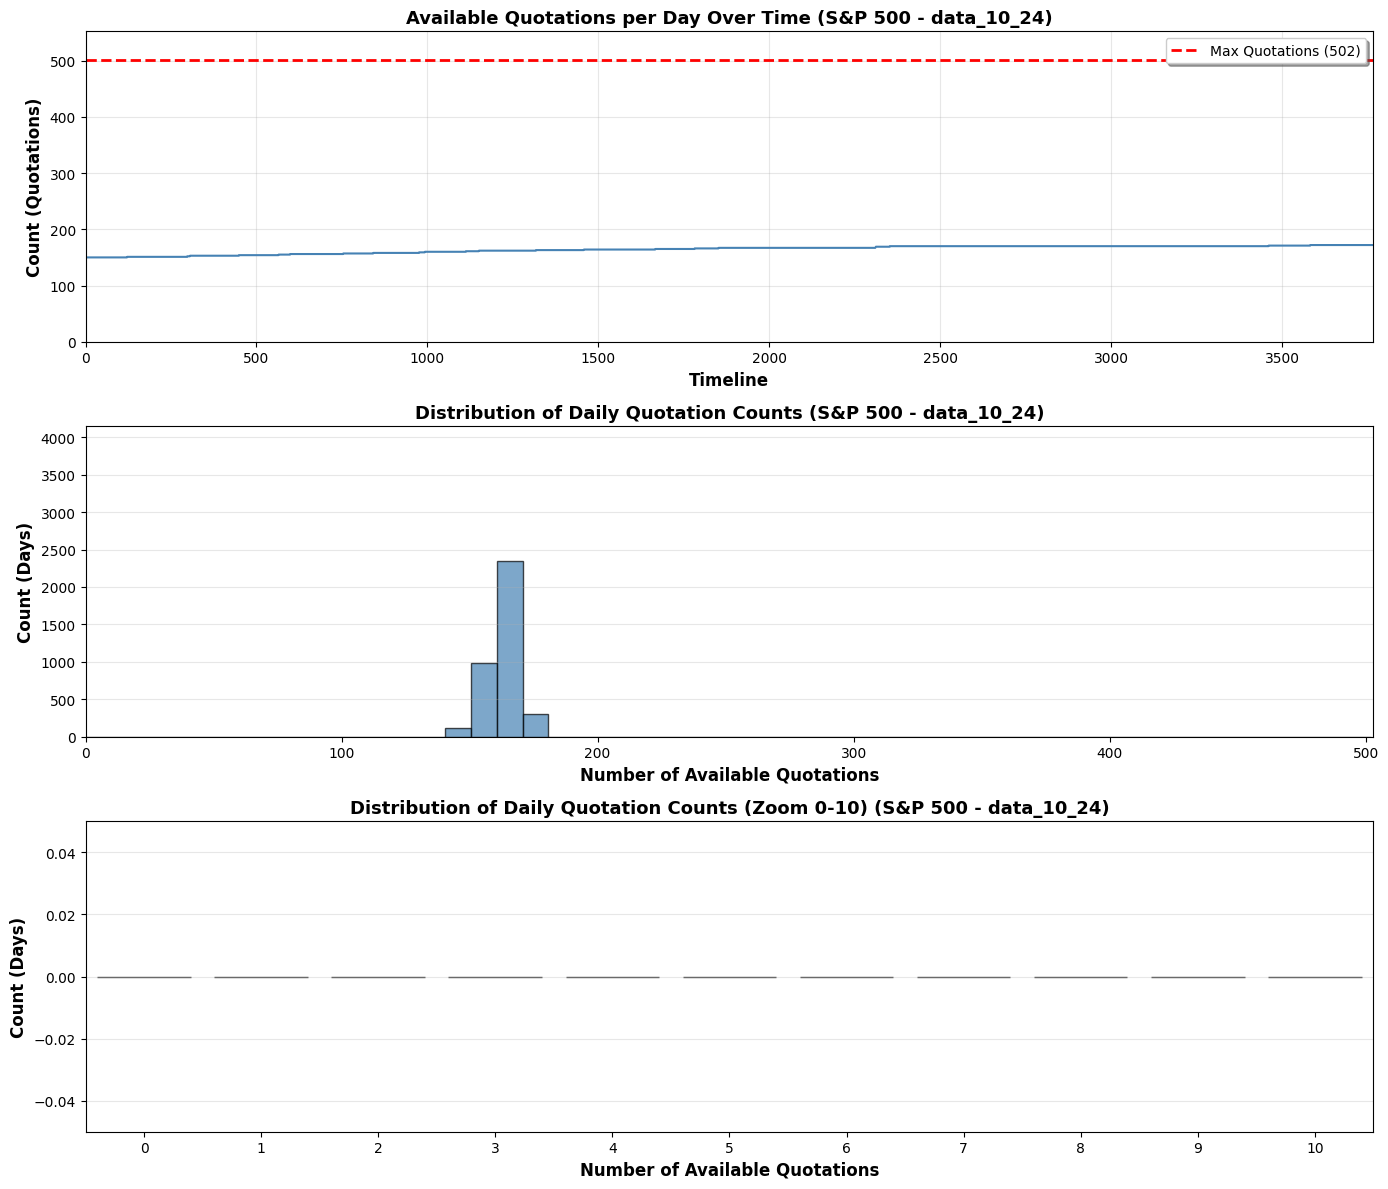

In [24]:
# Count available quotations per day (non-missing values across columns)
quotes_per_day = prices_df.notna().sum(axis=1)
max_quotes = prices_df.shape[1]  # Max possible quotations (all tickers available)

print(f"Quotations per day (across all tickers):")
print(f"Min: {quotes_per_day.min():.0f}")
print(f"Max: {quotes_per_day.max():.0f}")
print(f"Mean: {quotes_per_day.mean():.2f}")
print(f"Std: {quotes_per_day.std():.2f}")

# Plot using the reusable function
plot_quotations_per_day(quotes_per_day, max_quotes, FILE_NAME, 
                       is_filtered=False, n_days=prices_df.shape[0])

Days removed: 0
Days retained: 3768
Filtered dataset shape: (3768, 502)

Filtered days statistics:
Min quotations: 150
Max quotations: 172
Mean quotations: 163.97
Std quotations: 6.76


C:\Users\dylan\AppData\Local\Temp\ipykernel_11172\2384116002.py:62: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, counts.max() * 1.1)


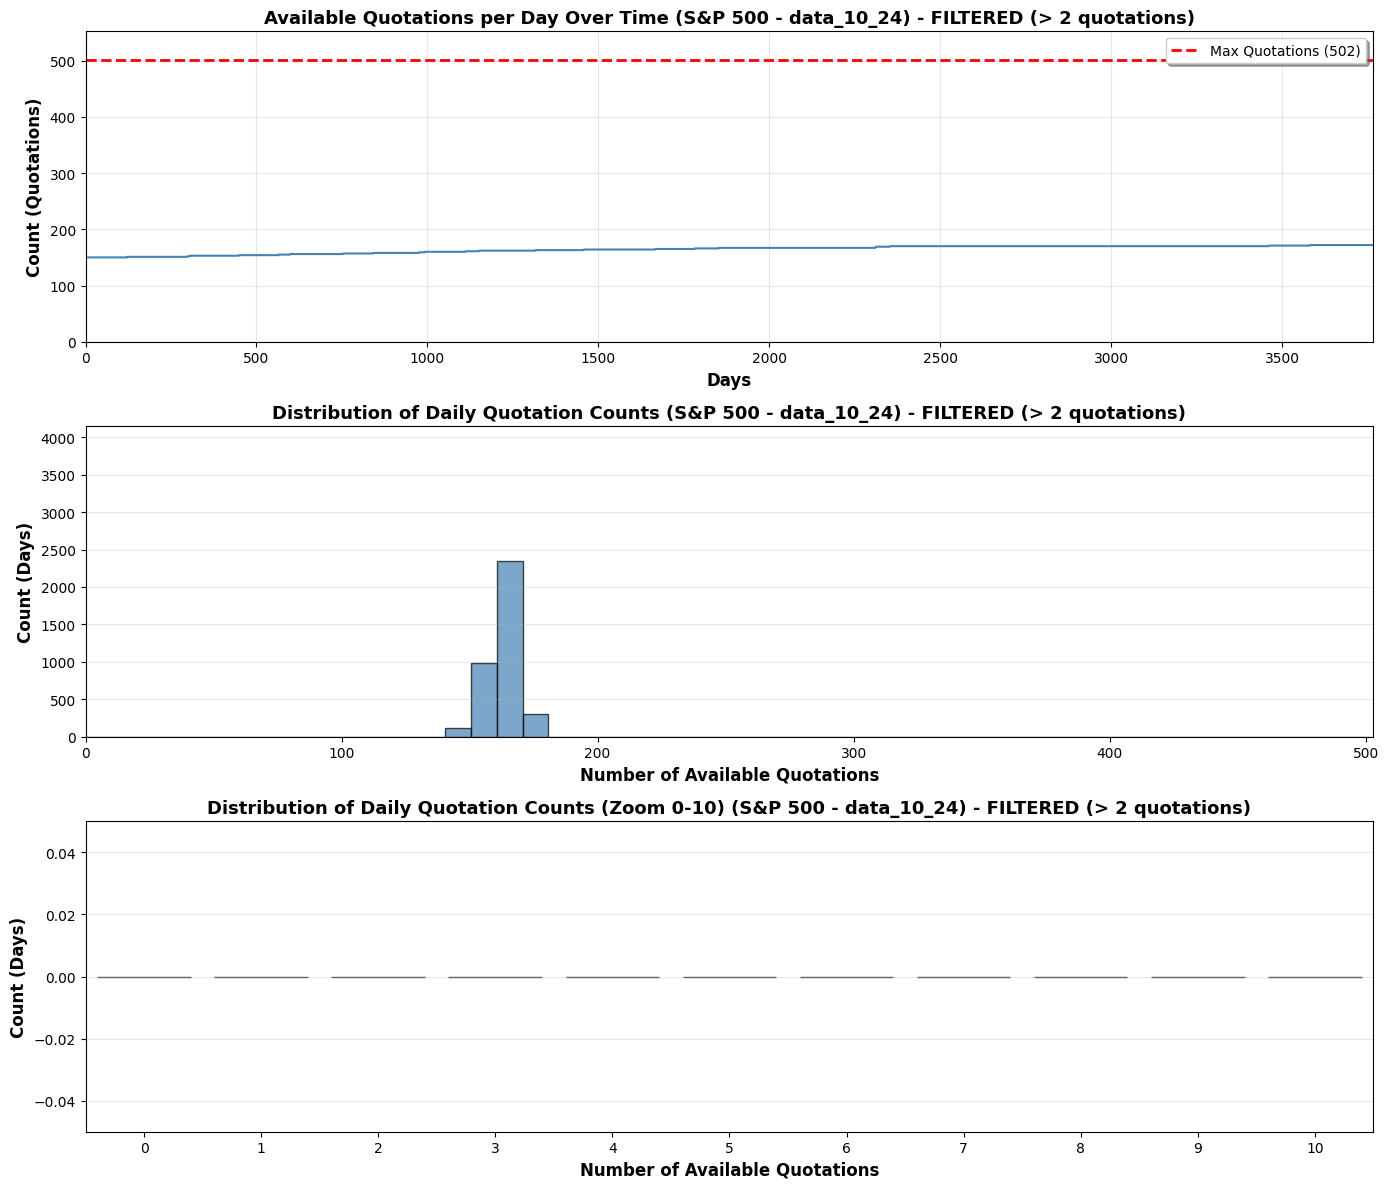

In [25]:
# Filter out days with less than or equal to MIN_QUOTES_PER_DAY quotations

MIN_QUOTES_PER_DAY = 2
valid_days_mask = quotes_per_day > MIN_QUOTES_PER_DAY
valid_day_indices = valid_days_mask[valid_days_mask].index.tolist()
max_quotes = prices_df.shape[1]  # Max possible quotations (all tickers available)

# Create filtered dataset
prices_filtered_df = prices_df.loc[valid_day_indices].copy()
quotes_per_day_filtered = quotes_per_day[valid_day_indices].copy()

print(f"Days removed: {(~valid_days_mask).sum()}")
print(f"Days retained: {valid_days_mask.sum()}")
print(f"Filtered dataset shape: {prices_filtered_df.shape}")
print(f"\nFiltered days statistics:")
print(f"Min quotations: {quotes_per_day_filtered.min():.0f}")
print(f"Max quotations: {quotes_per_day_filtered.max():.0f}")
print(f"Mean quotations: {quotes_per_day_filtered.mean():.2f}")
print(f"Std quotations: {quotes_per_day_filtered.std():.2f}")

# Plot using the reusable function with filtered data
plot_quotations_per_day(quotes_per_day_filtered, max_quotes, FILE_NAME,
                       is_filtered=True, min_quotes=MIN_QUOTES_PER_DAY, 
                       n_days=prices_df.shape[0])

In [26]:
# ===== AFTER FILTERING: Recalculate missing values per ticker =====
print("\n" + "="*70)
print("AFTER DAY FILTERING:")
print("="*70)

# Check for missing values in filtered dataset
missing_per_col_filtered = prices_filtered_df.isna().sum()
total_missing_filtered = int(missing_per_col_filtered.sum())
n_cells_filtered = prices_filtered_df.shape[0] * prices_filtered_df.shape[1]
missing_pct_filtered = (total_missing_filtered / n_cells_filtered) * 100

print("\nMissing values per ticker (after filtering):")
# Sort by missing values descending
missing_sorted_filtered = missing_per_col_filtered.sort_values(ascending=False)
sorted_tickers_filtered = missing_sorted_filtered.index.tolist()

for ticker in sorted_tickers_filtered:
    print(f"{ticker}: {missing_per_col_filtered[ticker]}")

print(f"\nTotal missing values (filtered): {total_missing_filtered}")
print(f"Missing percentage (filtered): {missing_pct_filtered:.2f}%")

# ===== FILTER TICKERS: Keep only those with 0 missing values =====
print("\n" + "="*70)
print("FILTERING TICKERS: Keep only those with ZERO missing values")
print("="*70)

# Identify tickers with NO missing values
no_missing_mask = missing_per_col_filtered == 0
tickers_with_complete_data = no_missing_mask[no_missing_mask].index.tolist()

# Filter the dataset to keep only complete tickers
prices_complete_df = prices_filtered_df[tickers_with_complete_data].copy()

# Validation prints
print(f"\nTickers with NO missing values: {no_missing_mask.sum()}")
print(f"Tickers removed (with missing values): {(~no_missing_mask).sum()}")
print(f"Final complete dataset shape: {prices_complete_df.shape}")
print(f"\nTickers with complete data ({len(tickers_with_complete_data)} total):")
print(tickers_with_complete_data)


AFTER DAY FILTERING:

Missing values per ticker (after filtering):
ZTS: 3768
A: 3768
AAPL: 3768
ZBRA: 3768
ABNB: 3768
WBD: 3768
WBA: 3768
WAT: 3768
WAB: 3768
VZ: 3768
VTR: 3768
VST: 3768
VRSN: 3768
VMC: 3768
AON: 3768
AMTM: 3768
AMT: 3768
AMGN: 3768
AME: 3768
AMD: 3768
AMCR: 3768
AMAT: 3768
ALGN: 3768
BALL: 3768
BAC: 3768
BA: 3768
AZO: 3768
AWK: 3768
AVY: 3768
AVGO: 3768
AVB: 3768
ATO: 3768
ARE: 3768
APTV: 3768
APD: 3768
APA: 3768
VICI: 3768
URI: 3768
UNP: 3768
UNH: 3768
ULTA: 3768
TYL: 3768
TXT: 3768
TXN: 3768
BRK-B: 3768
BR: 3768
BMY: 3768
BLK: 3768
BKNG: 3768
BIIB: 3768
BG: 3768
BF-B: 3768
TSCO: 3768
TRV: 3768
TROW: 3768
TRMB: 3768
TRGP: 3768
TPR: 3768
TPL: 3768
TMUS: 3768
TMO: 3768
TGT: 3768
TFX: 3768
TFC: 3768
CDW: 3768
CDNS: 3768
CCI: 3768
CBRE: 3768
CBOE: 3768
CB: 3768
CARR: 3768
CAH: 3768
CAG: 3768
BXP: 3768
BX: 3768
CMS: 3768
CMI: 3768
CMG: 3768
CL: 3768
CINF: 3768
CI: 3768
CHTR: 3768
CHRW: 3768
CHD: 3768
CFG: 3768
CF: 3768
CEG: 3768
CRWD: 3768
CRL: 3768
CPT: 3768
CPRT: 3768


## 3. Saving Filtered Data to CSV

In [27]:
# Add timestamp column at the beginning
df_complete = prices_complete_df.copy()
df_complete.insert(0, 'timestamp', df['timestamp'].iloc[valid_day_indices].reset_index(drop=True))

# Define output path
output_path = Path('../data/processed/cleaned_' + FILE_NAME + '.csv')

# Save to CSV
df_complete.to_csv(output_path, index=False)

print(f"\nFiltered dataset saved to: {output_path}")
print(f"Shape: {df_complete.shape} (rows=days, columns=tickers+timestamp)")
print(f"\nTimestamp range in filtered data:")
print(f"  From: {df_complete['timestamp'].min()}")
print(f"  To: {df_complete['timestamp'].max()}")
print(f"\nFirst few rows:")
print(df_complete.head())


Filtered dataset saved to: ..\data\processed\cleaned_data_10_24.csv
Shape: (3768, 151) (rows=days, columns=tickers+timestamp)

Timestamp range in filtered data:
  From: 2010-01-04 00:00:00
  To: 2024-12-20 00:00:00

First few rows:
   timestamp        ABT        ADM       AES        AJG        ALB        ALL  \
0 2010-01-04  18.763718  21.239878  9.370146  15.105777  30.864571  21.624144   
1 2010-01-05  18.612118  21.354618  9.274181  15.024599  30.807838  21.979689   
2 2010-01-06  18.715481  21.300613  9.178215  15.031368  30.864571  21.986795   
3 2010-01-07  18.870522  21.077894  9.185070  14.936652  30.645794  22.100569   
4 2010-01-08  18.966991  20.814674  9.445544  14.977247  31.107672  22.193012   

         AMP    AMZN       ANSS  ...       VRSK       VRTX       VTRS  \
0  28.856031  6.6950  44.639999  ...  28.723242  44.240002  16.079443   
1  29.528982  6.7345  43.639999  ...  28.915695  42.779999  15.907653   
2  29.941406  6.6125  43.349998  ...  29.290972  42.029999  1